In [ ]:
import pandas as pd
import kagglehub
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")
print(os.listdir(path))
csv_path = os.path.join(path, "dirty_cafe_sales.csv")
amazon = pd.read_csv(csv_path)

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.
['dirty_cafe_sales.csv']


In [11]:
import pandas as pd
import kagglehub
import os
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

# Re-download the dataset to ensure we have the latest version for this new pipeline
path = kagglehub.dataset_download("ahmedmohamed2003/cafe-sales-dirty-data-for-cleaning-training")
csv_path = os.path.join(path, "dirty_cafe_sales.csv")

df = pd.read_csv(csv_path)

print("First 5 rows of the raw dataset:")
display(df.head())
print("\nDataset Information:")
df.info()
print("\nUnique values per column:")
display(df.nunique().to_frame(name='Count of unique values'))
print("\nSample unique values per column (for object types):")
display(df.apply(lambda x: x.unique() if x.dtype == 'object' else None).dropna().to_frame(name='Unique Values'))
print("\nMissing values per column:")
display(df.isnull().sum())

Using Colab cache for faster access to the 'cafe-sales-dirty-data-for-cleaning-training' dataset.
First 5 rows of the raw dataset:


,Transaction ID,Item,Quantity,Price Per Unit,Total Spent,Payment Method,Location,Transaction Date
0,TXN_1961373,Coffee,2,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4,1.0,ERROR,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2,5.0,10.0,UNKNOWN,UNKNOWN,2023-04-27
4,TXN_3160411,Coffee,2,2.0,4.0,Digital Wallet,In-store,2023-06-11



Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   Transaction ID    10000 non-null  object
 1   Item              9667 non-null   object
 2   Quantity          9862 non-null   object
 3   Price Per Unit    9821 non-null   object
 4   Total Spent       9827 non-null   object
 5   Payment Method    7421 non-null   object
 6   Location          6735 non-null   object
 7   Transaction Date  9841 non-null   object
dtypes: object(8)
memory usage: 625.1+ KB

Unique values per column:


,Count of unique values
Transaction ID,10000
Item,10
Quantity,7
Price Per Unit,8
Total Spent,19
Payment Method,5
Location,4
Transaction Date,367



Sample unique values per column (for object types):


,Unique Values
Transaction ID,"[TXN_1961373, TXN_4977031, TXN_4271903, TXN_70..."
Item,"[Coffee, Cake, Cookie, Salad, Smoothie, UNKNOW..."
Quantity,"[2, 4, 5, 3, 1, ERROR, UNKNOWN, nan]"
Price Per Unit,"[2.0, 3.0, 1.0, 5.0, 4.0, 1.5, nan, ERROR, UNK..."
Total Spent,"[4.0, 12.0, ERROR, 10.0, 20.0, 9.0, 16.0, 15.0..."
Payment Method,"[Credit Card, Cash, UNKNOWN, Digital Wallet, E..."
Location,"[Takeaway, In-store, UNKNOWN, nan, ERROR]"
Transaction Date,"[2023-09-08, 2023-05-16, 2023-07-19, 2023-04-2..."



Missing values per column:


,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


In [12]:
df.columns = df.columns.str.lower().str.replace(' ', '_')

# 2. Numeric Conversion and Error Handling
for col in ['quantity', 'price_per_unit', 'total_spent']:
    df[col] = pd.to_numeric(df[col], errors='coerce')
    df[col] = df[col].fillna(0) # Fill NaN values with 0 after conversion

# 3. String Cleaning and Missing Values
df['item'] = df['item'].replace('UNKNOWN', 'Other').fillna('Other')
df['payment_method'] = df['payment_method'].replace('UNKNOWN', 'Other').fillna('Other')
df['location'] = df['location'].replace(['UNKNOWN', 'ERROR'], 'Other').fillna('Other')

# 4. Date Conversion
df['transaction_date'] = pd.to_datetime(df['transaction_date'], errors='coerce')
# Drop rows where transaction_date conversion failed, as they are invalid
df.dropna(subset=['transaction_date'], inplace=True)

print("\nDataset Information after Cleaning:")
df.info()
print("\nMissing values after Cleaning:")
display(df.isnull().sum())
print("\nFirst 5 rows of the cleaned dataset:")
display(df.head())


Dataset Information after Cleaning:
<class 'pandas.core.frame.DataFrame'>
Index: 9540 entries, 0 to 9999
Data columns (total 8 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   transaction_id    9540 non-null   object        
 1   item              9540 non-null   object        
 2   quantity          9540 non-null   float64       
 3   price_per_unit    9540 non-null   float64       
 4   total_spent       9540 non-null   float64       
 5   payment_method    9540 non-null   object        
 6   location          9540 non-null   object        
 7   transaction_date  9540 non-null   datetime64[ns]
dtypes: datetime64[ns](1), float64(3), object(4)
memory usage: 670.8+ KB

Missing values after Cleaning:


,0
transaction_id,0
item,0
quantity,0
price_per_unit,0
total_spent,0
payment_method,0
location,0
transaction_date,0



First 5 rows of the cleaned dataset:


,transaction_id,item,quantity,price_per_unit,total_spent,payment_method,location,transaction_date
0,TXN_1961373,Coffee,2.0,2.0,4.0,Credit Card,Takeaway,2023-09-08
1,TXN_4977031,Cake,4.0,3.0,12.0,Cash,In-store,2023-05-16
2,TXN_4271903,Cookie,4.0,1.0,0.0,Credit Card,In-store,2023-07-19
3,TXN_7034554,Salad,2.0,5.0,10.0,Other,Other,2023-04-27
4,TXN_3160411,Coffee,2.0,2.0,4.0,Digital Wallet,In-store,2023-06-11


## Key Performance Indicators (KPIs)

Let's calculate and visualize the requested KPIs using the cleaned `df` DataFrame.

### 1. Revenue by Product

/tmp/ipykernel_2661/1195791464.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_product.index, y=revenue_by_product.values, palette='viridis')


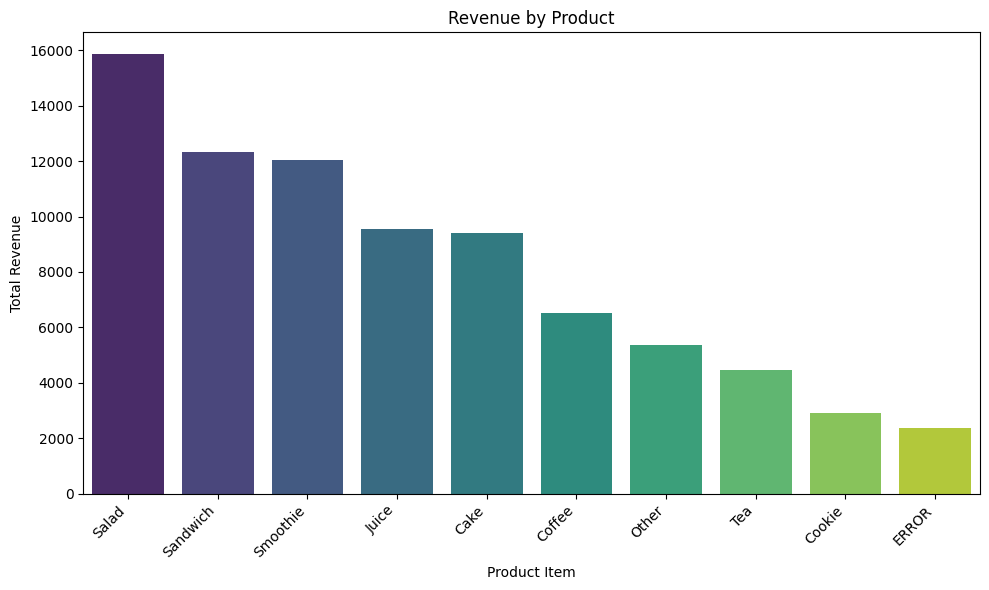

,total_spent
item,
Salad,15855.0
Sandwich,12328.0
Smoothie,12040.0
Juice,9540.0
Cake,9393.0


In [13]:
revenue_by_product = df.groupby('item')['total_spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_product.index, y=revenue_by_product.values, palette='viridis')
plt.title('Revenue by Product')
plt.xlabel('Product Item')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(revenue_by_product.head())

### 2. Revenue by Location

/tmp/ipykernel_2661/1230931923.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_location.index, y=revenue_by_location.values, palette='plasma')


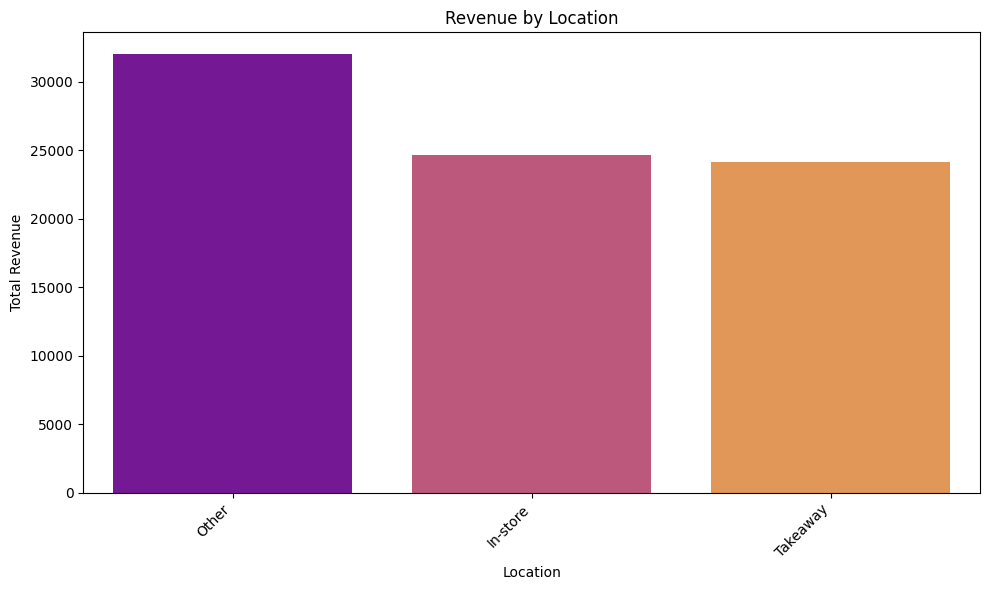

,total_spent
location,
Other,32001.0
In-store,24650.0
Takeaway,24149.5


In [14]:
revenue_by_location = df.groupby('location')['total_spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=revenue_by_location.index, y=revenue_by_location.values, palette='plasma')
plt.title('Revenue by Location')
plt.xlabel('Location')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(revenue_by_location.head())

### 3. Revenue by Payment Method

/tmp/ipykernel_2661/3706846395.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=revenue_by_payment_method.index, y=revenue_by_payment_method.values, palette='coolwarm')


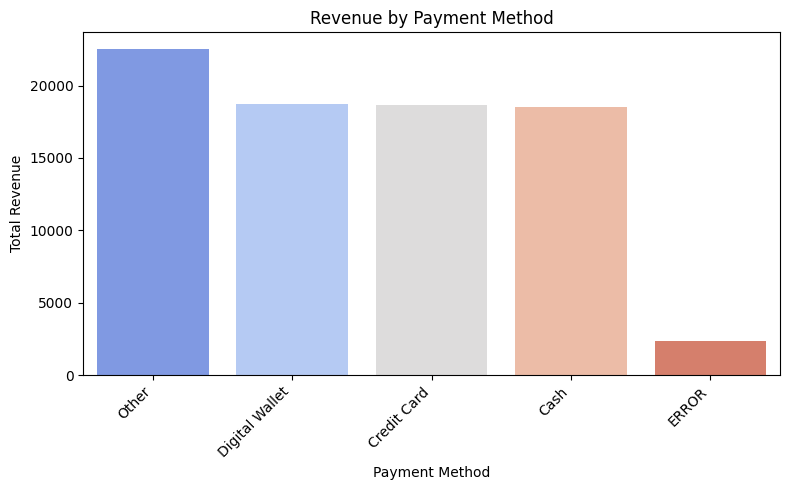

,total_spent
payment_method,
Other,22551.0
Digital Wallet,18719.5
Credit Card,18654.0
Cash,18489.5
ERROR,2386.5


In [15]:
revenue_by_payment_method = df.groupby('payment_method')['total_spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(8, 5))
sns.barplot(x=revenue_by_payment_method.index, y=revenue_by_payment_method.values, palette='coolwarm')
plt.title('Revenue by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(revenue_by_payment_method.head())

### 4. Weekend vs Weekday Sales

/tmp/ipykernel_2661/3324868055.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=weekend_vs_weekday_sales.index, y=weekend_vs_weekday_sales.values, palette='Blues')


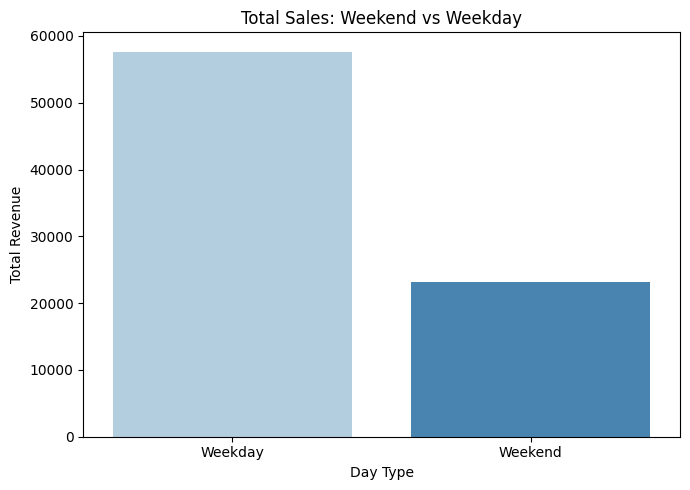

,total_spent
is_weekend,
Weekday,57650.0
Weekend,23150.5


In [16]:
df['day_of_week'] = df['transaction_date'].dt.dayofweek
df['is_weekend'] = df['day_of_week'].apply(lambda x: 'Weekend' if x >= 5 else 'Weekday')

weekend_vs_weekday_sales = df.groupby('is_weekend')['total_spent'].sum().sort_values(ascending=False)

plt.figure(figsize=(7, 5))
sns.barplot(x=weekend_vs_weekday_sales.index, y=weekend_vs_weekday_sales.values, palette='Blues')
plt.title('Total Sales: Weekend vs Weekday')
plt.xlabel('Day Type')
plt.ylabel('Total Revenue')
plt.tight_layout()
plt.show()

display(weekend_vs_weekday_sales)

### 5. Peak Sales Day

The peak sales day was 2023-07-24 with total sales of $365.50.


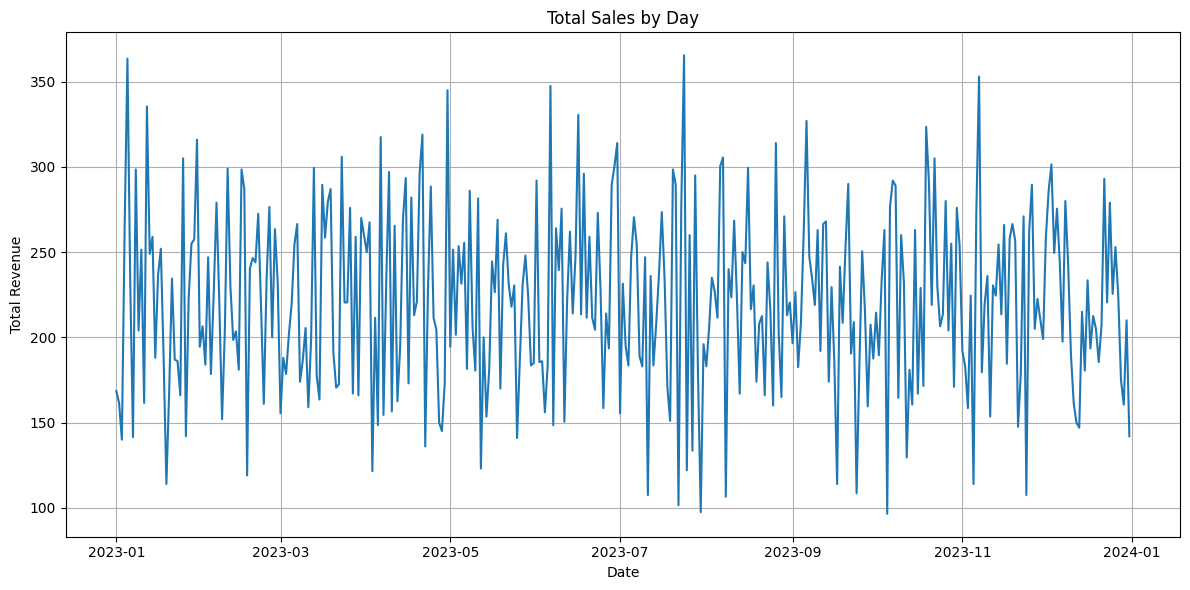

In [17]:
sales_by_day = df.groupby(df['transaction_date'].dt.date)['total_spent'].sum()
peak_sales_day = sales_by_day.idxmax()
max_sales_amount = sales_by_day.max()

print(f"The peak sales day was {peak_sales_day} with total sales of ${max_sales_amount:.2f}.")

plt.figure(figsize=(12, 6))
sales_by_day.plot(kind='line')
plt.title('Total Sales by Day')
plt.xlabel('Date')
plt.ylabel('Total Revenue')
plt.grid(True)
plt.tight_layout()
plt.show()

### 6. Best Selling Item (by Quantity)

/tmp/ipykernel_2661/1494949405.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=best_selling_item_quantity.index, y=best_selling_item_quantity.values, palette='rocket')


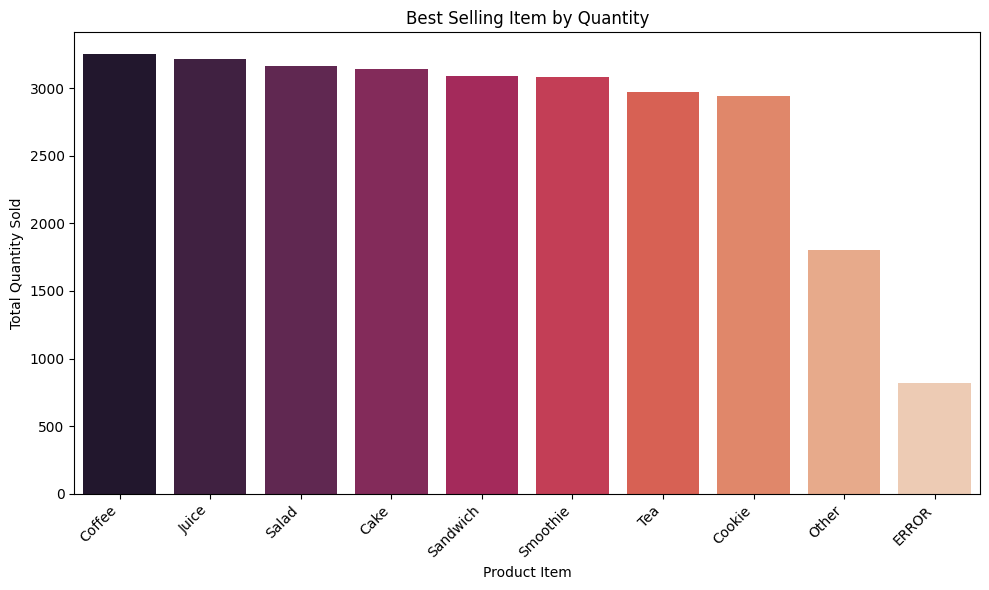

,quantity
item,
Coffee,3251.0
Juice,3216.0
Salad,3161.0
Cake,3143.0
Sandwich,3089.0


In [18]:
best_selling_item_quantity = df.groupby('item')['quantity'].sum().sort_values(ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x=best_selling_item_quantity.index, y=best_selling_item_quantity.values, palette='rocket')
plt.title('Best Selling Item by Quantity')
plt.xlabel('Product Item')
plt.ylabel('Total Quantity Sold')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

display(best_selling_item_quantity.head())

### 7. Product Revenue Contribution (%)

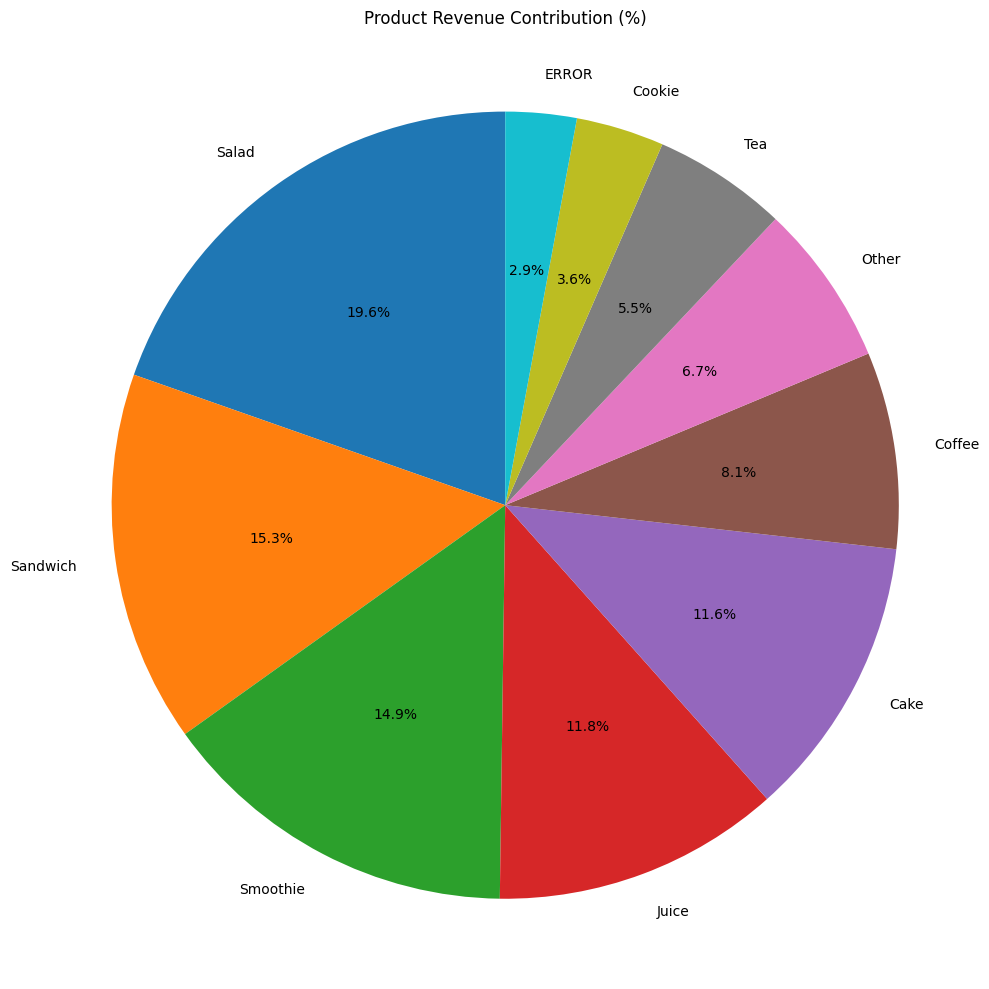

,total_spent
item,
Salad,19.622403
Sandwich,15.257331
Smoothie,14.900898
Juice,11.806858
Cake,11.624928


In [24]:
total_revenue = df['total_spent'].sum()
product_revenue_contribution = (df.groupby('item')['total_spent'].sum() / total_revenue * 100).sort_values(ascending=False)

plt.figure(figsize=(10, 10))
plt.pie(product_revenue_contribution, labels=product_revenue_contribution.index, autopct='%1.1f%%', startangle=90)
plt.title('Product Revenue Contribution (%)')
plt.axis('equal') # Equal aspect ratio ensures that pie is drawn as a circle.
plt.tight_layout()
plt.show()

display(product_revenue_contribution.head())

### 8. Transaction Success Rate

In [22]:
# Assuming a 'successful' transaction is one where total_spent is greater than 0 after cleaning.
successful_transactions = df[df['total_spent'] > 0].shape[0]
total_transactions = df.shape[0]
transaction_success_rate = (successful_transactions / total_transactions) * 100

print(f"Total transactions: {total_transactions}")
print(f"Successful transactions (total_spent > 0): {successful_transactions}")
print(f"Transaction Success Rate: {transaction_success_rate:.2f}%")

Total transactions: 9540
Successful transactions (total_spent > 0): 9064
Transaction Success Rate: 95.01%


### 9. Missing Data Rate (Original Dataset)

In [25]:
total_cells_original = amazon.shape[0] * amazon.shape[1]
missing_cells_original = amazon.isnull().sum().sum()
missing_data_rate_original = (missing_cells_original / total_cells_original) * 100

print(f"Total cells in original dataset: {total_cells_original}")
print(f"Total missing cells in original dataset: {missing_cells_original}")
print(f"Missing Data Rate (Original Dataset): {missing_data_rate_original:.2f}%")

print("\nMissing values per column in original dataset:")
display(amazon.isnull().sum())

Total cells in original dataset: 80000
Total missing cells in original dataset: 6826
Missing Data Rate (Original Dataset): 8.53%

Missing values per column in original dataset:


,0
Transaction ID,0
Item,333
Quantity,138
Price Per Unit,179
Total Spent,173
Payment Method,2579
Location,3265
Transaction Date,159


### 10. Invalid Date Percentage (Original Dataset)

In [26]:
original_transaction_dates = pd.to_datetime(amazon['Transaction Date'], errors='coerce')
invalid_dates_count = original_transaction_dates.isnull().sum()
total_dates = amazon.shape[0]
invalid_date_percentage = (invalid_dates_count / total_dates) * 100

print(f"Total transaction dates in original dataset: {total_dates}")
print(f"Number of invalid dates: {invalid_dates_count}")
print(f"Invalid Date Percentage (Original Dataset): {invalid_date_percentage:.2f}%")

Total transaction dates in original dataset: 10000
Number of invalid dates: 460
Invalid Date Percentage (Original Dataset): 4.60%
